# Load datasets
This step loads the two datasets: GoEmotions (kaggle) and Political tweets(huggingface).
The datasets are cleaned, the GoEmotions dataset emotions are reduced to 10, and finally the datasets are combined into one clean dataset. 

In [1]:
!pip install datasets

In [2]:
import pandas as pd

url = "https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_1.csv"
goemotions = pd.read_csv(url)

print(goemotions.head())
print(goemotions.columns)

                                                text       id  \
0                                    That game hurt.  eew5j0j   
1   >sexuality shouldn’t be a grouping category I...  eemcysk   
2     You do right, if you don't care then fuck 'em!  ed2mah1   
3                                 Man I love reddit.  eeibobj   
4  [NAME] was nowhere near them, he was by the Fa...  eda6yn6   

                author            subreddit    link_id   parent_id  \
0                Brdd9                  nrl  t3_ajis4z  t1_eew18eq   
1          TheGreen888     unpopularopinion  t3_ai4q37   t3_ai4q37   
2             Labalool          confessions  t3_abru74  t1_ed2m7g7   
3        MrsRobertshaw             facepalm  t3_ahulml   t3_ahulml   
4  American_Fascist713  starwarsspeculation  t3_ackt2f  t1_eda65q2   

    created_utc  rater_id  example_very_unclear  admiration  ...  love  \
0  1.548381e+09         1                 False           0  ...     0   
1  1.548084e+09        37               

In [3]:
# political dataset from huggingface download + convert to df
from datasets import load_dataset

political = load_dataset("tweet_eval", "sentiment")
print(political)
train_df = political["train"].to_pandas()
test_df = political["test"].to_pandas()

# export file
train_df.to_csv("tweet_eval_sentiment.csv", index=False)

tweets = pd.concat([train_df, test_df], ignore_index=True)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [4]:
# rename columns
tweets = tweets.rename(columns={"text": "text", "label": "label"})

In [5]:
import re

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+", "", text)   # remove links
    text = re.sub(r"@\w+", "", text)      # remove mentions
    text = re.sub(r"#\w+", "", text)      # remove hashtags
    text = re.sub(r"[^a-z\s]", "", text)  # remove special chars
    text = re.sub(r"\s+", " ", text).strip()
    return text

goemotions["text"] = goemotions["text"].apply(clean_text)
tweets["text"] = tweets["text"].apply(clean_text)

In [6]:
goemotions.head()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,that game hurt,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,sexuality shouldnt be a grouping category it m...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,you do right if you dont care then fuck em,ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1
3,man i love reddit,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,1,0,0,0,0,0,0,0,0,0
4,name was nowhere near them he was by the falcon,eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,1


In [7]:
tweets.head()

,text,label
0,qt in the original draft of the th book remus ...,2
1,ben smith smith concussion remains out of the ...,1
2,sorry bout the stream last night i crashed out...,1
3,chase headleys rbi double in the th inning off...,1
4,alciato bee will invest million in january ano...,2


In [8]:
# clean text
import re

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+", "", text)   # remove links
    text = re.sub(r"@\w+", "", text)      # remove mentions
    text = re.sub(r"#\w+", "", text)      # remove hashtags
    text = re.sub(r"[^a-z\s]", "", text)  # remove special chars
    text = re.sub(r"\s+", " ", text).strip()
    return text

goemotions["text"] = goemotions["text"].apply(clean_text)
tweets["text"] = tweets["text"].apply(clean_text)

In [9]:
#reduce to 10 emotions
emotion_map = {
    "joy": ["joy", "amusement", "excitement"],
    "love": ["love", "caring", "admiration"],
    "optimism": ["optimism", "desire", "approval"],
    "gratitude": ["gratitude", "relief", "pride"],
    
    "anger": ["anger", "annoyance", "disapproval"],
    "disgust": ["disgust"],
    "fear": ["fear", "nervousness"],
    "sadness": ["sadness", "grief", "disappointment", "remorse"],
    "embarrassment": ["embarrassment"],
    
    "neutral": ["neutral", "confusion", "curiosity", "realization", "surprise"]
}

In [10]:
#convert goemotions to a single label
def map_emotions(row):
    for new_label, old_labels in emotion_map.items():
        for label in old_labels:
            if label in row and row[label] == 1:
                return new_label
    return "neutral"

goemotions["label"] = goemotions.apply(map_emotions, axis=1)

goemotions = goemotions[["text", "label"]]

In [11]:
# clean political tweets labels
def map_tweet(label):
    if label == 0:
        return "anger"
    elif label == 1:
        return "neutral"
    else:
        return "joy"

tweets["label"] = tweets["label"].apply(map_tweet)
tweets = tweets[["text", "label"]]

In [12]:
# combine datasets
df = pd.concat([goemotions, tweets], ignore_index=True)

print(df["label"].value_counts())

label
neutral          53020
joy              27364
anger            20155
love              9163
optimism          7999
sadness           4103
gratitude         3298
fear              1186
disgust           1105
embarrassment      506
Name: count, dtype: int64


In [13]:
from sklearn.preprocessing import LabelEncoder

# keep readable emotion labels
df["emotion_name"] = df["label"]

# encode numeric labels for BERT
le = LabelEncoder()
df["label"] = le.fit_transform(df["emotion_name"])

# mapping dictionary
label_map = dict(zip(le.classes_, le.transform(le.classes_)))

print(label_map)

{'anger': np.int64(0), 'disgust': np.int64(1), 'embarrassment': np.int64(2), 'fear': np.int64(3), 'gratitude': np.int64(4), 'joy': np.int64(5), 'love': np.int64(6), 'neutral': np.int64(7), 'optimism': np.int64(8), 'sadness': np.int64(9)}


In [14]:
# final dataset
print(df.head())
df.to_csv("cleaned_emotion_dataset.csv", index=False)

print("Dataset saved successfully")

                                                text  label emotion_name
0                                     that game hurt      9      sadness
1  sexuality shouldnt be a grouping category it m...      7      neutral
2         you do right if you dont care then fuck em      7      neutral
3                                  man i love reddit      6         love
4    name was nowhere near them he was by the falcon      7      neutral
Dataset saved successfully


In [15]:
# convert to hugging face dataset for BERT
from datasets import Dataset

dataset = Dataset.from_pandas(df)
dataset = dataset.train_test_split(test_size=0.1)

# Tokenization and Model Training

In [16]:
import sys

print(sys.executable)

C:\Users\pearl\anaconda3\python.exe


In [17]:
!pip install pandas numpy scikit-learn transformers datasets accelerate evaluate

In [18]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/torchvision-0.2.0-py2.py3-none-any.whl (48 kB)


ERROR: Could not find a version that satisfies the requirement torchaudio (from versions: none)
ERROR: No matching distribution found for torchaudio


In [19]:
# tokenizer - hugging face transformer
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# apply tokenization
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

dataset = dataset.map(tokenize, batched=True)

#set format for PyTorch
dataset = dataset.remove_columns(["text"])
dataset.set_format("torch")

Map:   0%|          | 0/115109 [00:00<?, ? examples/s]

Map:   0%|          | 0/12790 [00:00<?, ? examples/s]

In [20]:
import transformers
import pandas as pd
import numpy as np
import torch

print("All libraries imported successfully")

All libraries imported successfully


In [21]:
!python --version

Python 3.13.9


In [22]:
df = df.dropna()

df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(int)

In [23]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42
)

In [24]:
print(type(train_texts[0]))

print(train_texts[0])

<class 'str'>
name focus on local politics since its the easiest to hide your cheating and corruption down there


In [25]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

In [26]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=128
)

In [27]:
class EmotionDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)

In [28]:
train_dataset = EmotionDataset(
    train_encodings,
    train_labels
)

test_dataset = EmotionDataset(
    test_encodings,
    test_labels
)

In [29]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=10
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [30]:
import transformers
import accelerate

print(transformers.__version__)
print(accelerate.__version__)

5.9.0
1.13.0


In [31]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    max_steps=2000, 
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5
)

In [32]:
# trainer
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

print("Trainer created successfully")

Trainer created successfully


In [33]:
# train model
trainer.train()

C:\Users\pearl\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
0,1.128677,1.099415


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2000, training_loss=1.228931640625, metrics={'train_runtime': 19217.2417, 'train_samples_per_second': 1.665, 'train_steps_per_second': 0.104, 'total_flos': 637590307200000.0, 'train_loss': 1.228931640625, 'epoch': 0.3127443315089914})

In [41]:
# save trained model
trainer.save_model("./final_model")
tokenizer.save_pretrained("./final_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./final_model\\tokenizer_config.json', './final_model\\tokenizer.json')

In [42]:
# reload trained model
#from transformers import AutoModelForSequenceClassification, AutoTokenizer

#model = AutoModelForSequenceClassification.from_pretrained("./final_model")
#tokenizer = AutoTokenizer.from_pretrained("./final_model")

In [35]:
from sklearn.metrics import classification_report
predictions = trainer.predict(test_dataset)
preds = predictions.predictions.argmax(-1)

print(classification_report(test_labels, preds))

C:\Users\pearl\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

           0       0.52      0.46      0.48      3985
           1       0.00      0.00      0.00       222
           2       0.00      0.00      0.00        99
           3       0.00      0.00      0.00       232
           4       0.57      0.63      0.60       608
           5       0.67      0.61      0.64      5534
           6       0.51      0.56      0.53      1792
           7       0.61      0.75      0.67     10721
           8       0.44      0.16      0.24      1589
           9       0.37      0.29      0.33       798

    accuracy                           0.59     25580
   macro avg       0.37      0.35      0.35     25580
weighted avg       0.57      0.59      0.57     25580



C:\Users\pearl\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pearl\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pearl\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [45]:
label_names = {
    0: "anger",
    1: "disgust",
    2: "embarassment",
    3: "fear",
    4: "gratitude",
    5: "joy",
    6: "love",
    7: "neutral",
    8: "optimism",
    9: "sadness"
}

In [37]:
print(classification_report(test_labels, preds, target_names=list(label_names.values())))

               precision    recall  f1-score   support

      neutral       0.52      0.46      0.48      3985
          joy       0.00      0.00      0.00       222
        anger       0.00      0.00      0.00        99
         love       0.00      0.00      0.00       232
     optimism       0.57      0.63      0.60       608
      sadness       0.67      0.61      0.64      5534
    gratitude       0.51      0.56      0.53      1792
         fear       0.61      0.75      0.67     10721
      disgust       0.44      0.16      0.24      1589
embarrassment       0.37      0.29      0.33       798

     accuracy                           0.59     25580
    macro avg       0.37      0.35      0.35     25580
 weighted avg       0.57      0.59      0.57     25580



C:\Users\pearl\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pearl\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pearl\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [46]:
!pip install matplotlib seaborn

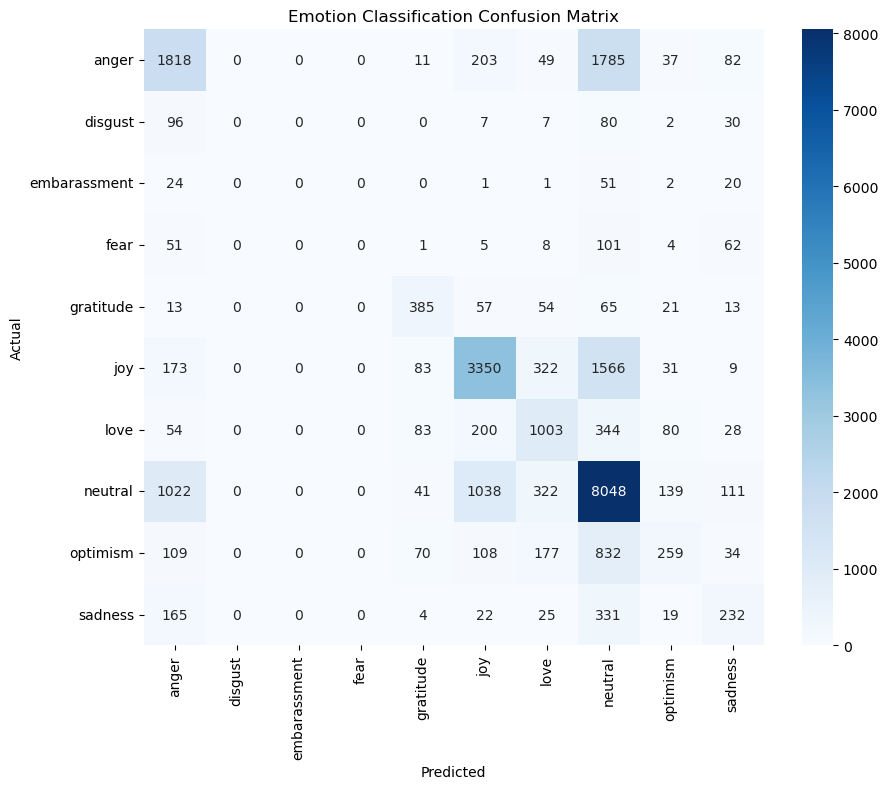

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, preds)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names.values(),
    yticklabels=label_names.values()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Emotion Classification Confusion Matrix")

plt.show()

# Testing

In [65]:
# test custom predictions
text = "I am excited for the election results!"

inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

outputs = model(**inputs)

predicted_class = outputs.logits.argmax().item()
predicted_label = label_names[predicted_class]

print("Predicted class:", predicted_class)
print("Predicted label:", predicted_label)

Predicted class: 5
Predicted label: joy
